<a href="https://colab.research.google.com/github/intanypurbasari/hello-world/blob/master/Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [1]:
from tensorflow.keras.datasets import fashion_mnist

# 1. Load Dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0 # Normalize
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# 2. Build Model
model_multi = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax') # Softmax for Multiclass
])

model_multi.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

model_multi.fit(x_train, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8237 - loss: 0.5017
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8632 - loss: 0.3775
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8755 - loss: 0.3390
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8850 - loss: 0.3142
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8916 - loss: 0.2946


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


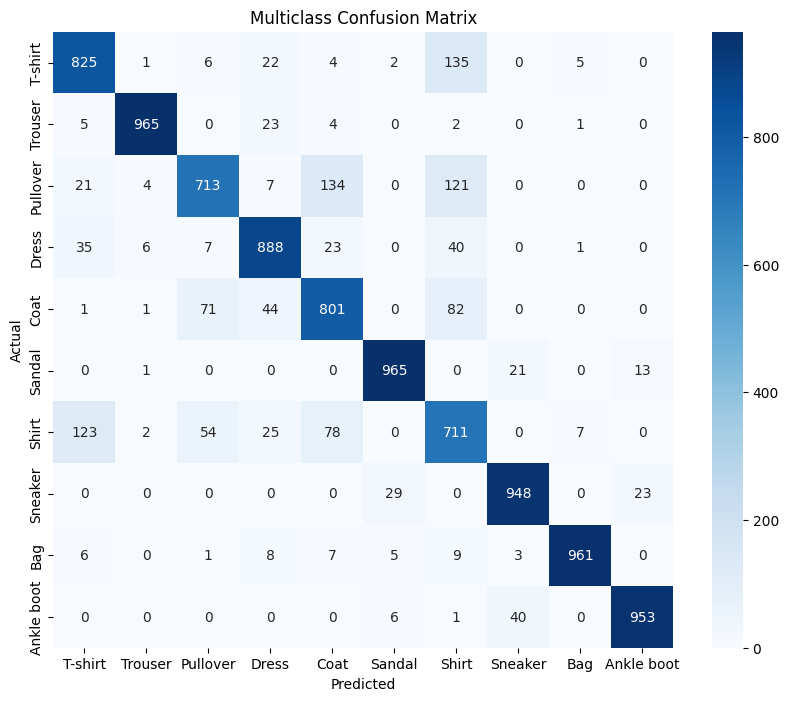

In [6]:
# 3. Evaluation & Confusion Matrix
y_pred_multi = np.argmax(model_multi.predict(x_test), axis=1)
cm_multi = confusion_matrix(y_test, y_pred_multi)

# Plotting
plt.figure(figsize=(10,8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Multiclass Confusion Matrix')
plt.show()

In [7]:
print(classification_report(y_test, y_pred_multi, target_names=class_names))

              precision    recall  f1-score   support

     T-shirt       0.81      0.82      0.82      1000
     Trouser       0.98      0.96      0.97      1000
    Pullover       0.84      0.71      0.77      1000
       Dress       0.87      0.89      0.88      1000
        Coat       0.76      0.80      0.78      1000
      Sandal       0.96      0.96      0.96      1000
       Shirt       0.65      0.71      0.68      1000
     Sneaker       0.94      0.95      0.94      1000
         Bag       0.99      0.96      0.97      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



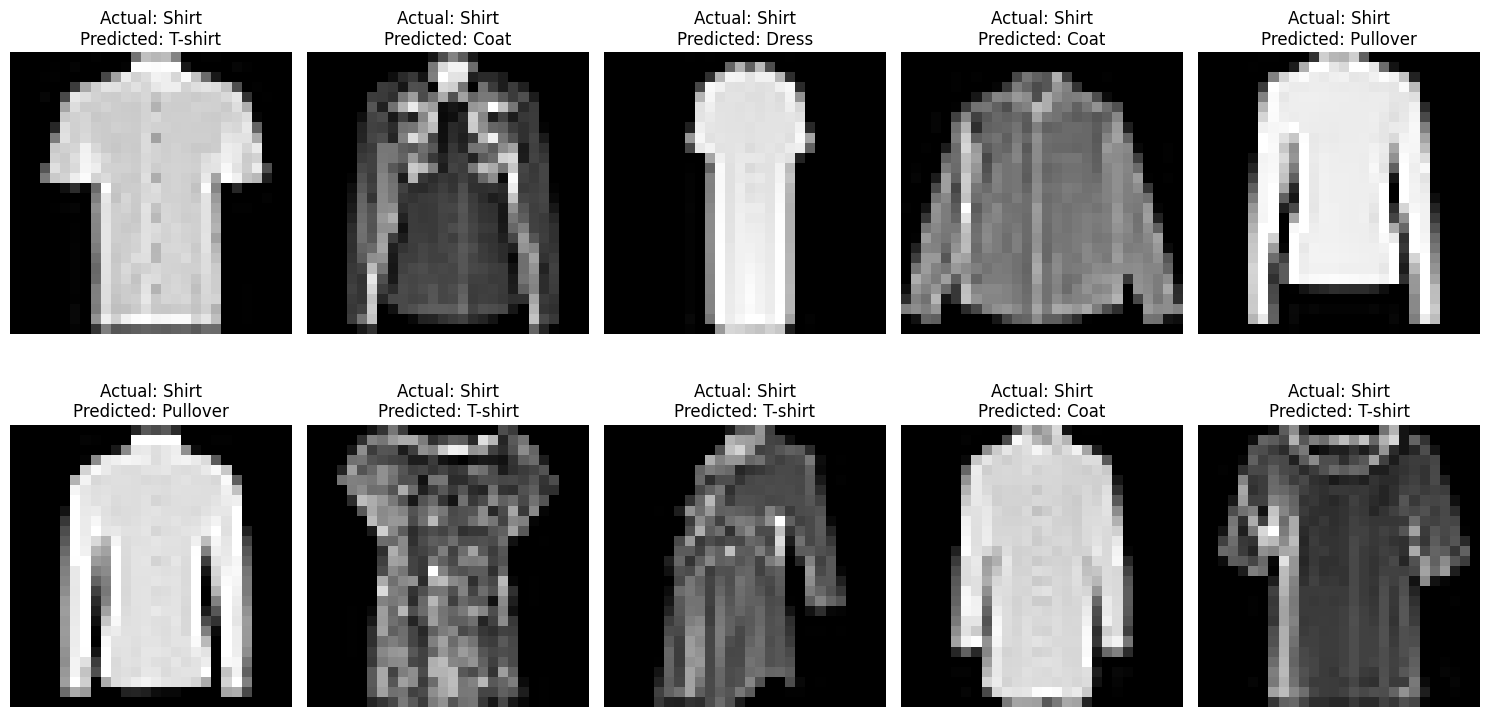

In [8]:
shirt_label_index = class_names.index('Shirt')
misclassified_shirt_indices = np.where((y_test == shirt_label_index) & (y_pred_multi != shirt_label_index))[0]

plt.figure(figsize=(15, 8))
for i, idx in enumerate(misclassified_shirt_indices[:10]): # Display up to 10 misclassified shirt images
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Actual: {class_names[y_test[idx]]}\nPredicted: {class_names[y_pred_multi[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()